# TELE-COMMUNICATION CHURN ANALYSIS

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

In [5]:
telCom_base_Data = pd.read_csv("/content/archive (6).zip")

In [6]:
telCom_base_Data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Senior Citizen is actually categorical hence the 25% - 50% -75% distribution is not proper

75% Customer have Tenure less than 55 months

In [7]:
telCom_base_Data.shape

(7043, 21)

In [8]:
telCom_base_Data.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

In [9]:
telCom_base_Data.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [10]:
telCom_base_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
telCom_base_Data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


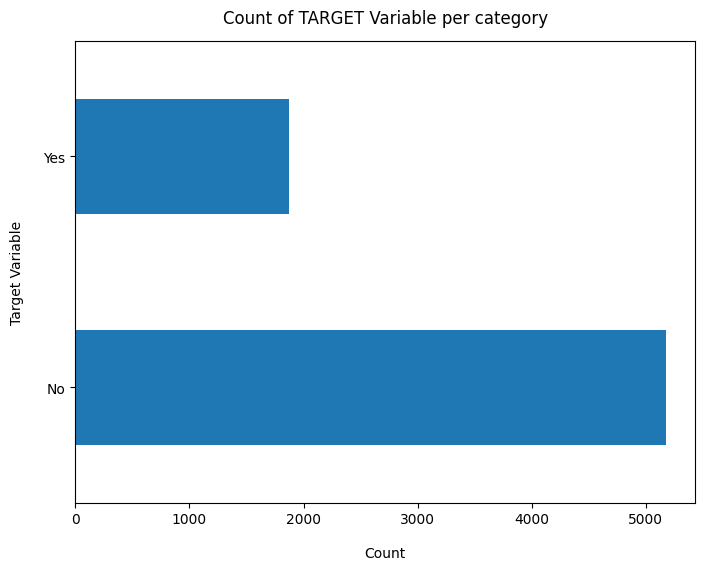

In [12]:
telCom_base_Data['Churn'].value_counts().plot(kind='barh', figsize=(8,6))
plt.xlabel("Count", labelpad=14) #Number of Customer
plt.ylabel("Target Variable", labelpad=14) #spacing between the number of axis and Target Variable
plt.title("Count of TARGET Variable per category", y=1.02)
plt.show()

ow many customers churned
✔ How many stayed
✔ Whether dataset is balanced or imbalanced

In [13]:
100*telCom_base_Data['Churn'].value_counts()/len(telCom_base_Data['Churn'])

,count
Churn,
No,73.463013
Yes,26.536987


5000 / 6800 = 0.73
1800 / 6800 = 0.26

In [14]:
telCom_base_Data['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


This means:

5174 customers stayed

1869 customers left

In [15]:
telCom_base_Data.info(verbose = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


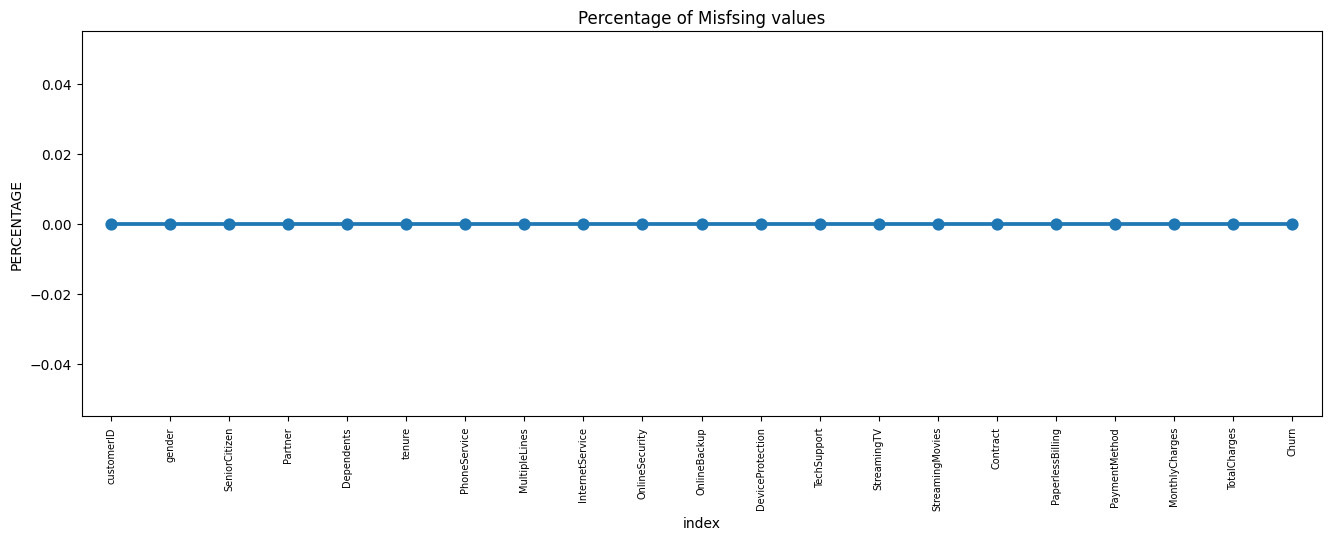

In [16]:
missing = pd.DataFrame((telCom_base_Data.isnull().sum())*100/telCom_base_Data.shape[0]).reset_index()
plt.figure(figsize=(16,5))
ax = sns.pointplot(x='index', y=0, data=missing)
plt.xticks(rotation=90, fontsize=7)
plt.title("Percentage of Misfsing values")
plt.ylabel("PERCENTAGE")
plt.show()

In [18]:
telCom_data = telCom_base_Data.copy()

Total Charges Should be numeric amount. let's convert it to numerical data types

In [19]:
telCom_base_Data['TotalCharges'] = pd.to_numeric(telCom_data.TotalCharges, errors='coerce')
telCom_base_Data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [20]:
telCom_base_Data.loc[telCom_base_Data['TotalCharges'].isnull() == True]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


## Ye line un sabhi rows ko display karegi jaha TotalCharges column me missing (NaN) value hai.

In [21]:
#0.15 % of these Records compared to total dataset just ignores
telCom_base_Data.dropna(how = 'any', inplace = True)

#telCom_base_Data.fillna(0)

Tenure = 1 → Customer 1 month se service use kar raha hai

Tenure = 24 → Customer 2 saal se service use kar raha hai

Tenure = 60 → Customer 5 saal se customer hai

In [22]:
# Get the max Tenure
print(telCom_base_Data['tenure'].max())

72


In [23]:
#Group the tenure in bins of 12th months
tenure_labels = []
# The bins range from 1 to 72 (max tenure), in steps of 12.
# range(1,80,12) will create bins up to 73, resulting in 6 bins.
# The loop below will correctly generate 6 labels for these 6 bins.
for i in range(1, 73, 12):
    start = i
    end = i + 11
    tenure_labels.append(f"{start}-{end}")

telCom_base_Data['tenure_group'] = pd.cut(telCom_base_Data.tenure, bins=range(1,80,12), right=False, labels=tenure_labels)

In [24]:
telCom_base_Data['tenure_group'] = pd.cut(telCom_base_Data.tenure, bins=range(1,80,12), right=False, labels=tenure_labels)

In [25]:
telCom_base_Data['tenure_group']

,tenure_group
0,1-12
1,25-36
2,1-12
3,37-48
4,1-12
...,...
7038,13-24
7039,61-72
7040,1-12
7041,1-12


In [26]:
#drop column customer ID and tenure
telCom_base_Data.drop(columns=['customerID','tenure'], axis=1, inplace=True)

In [27]:
telCom_base_Data.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1-12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25-36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1-12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37-48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1-12


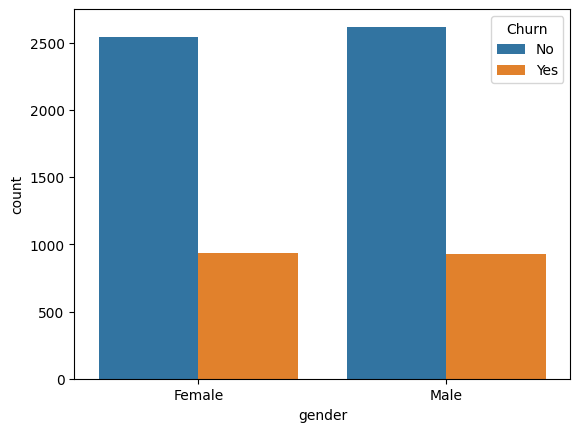

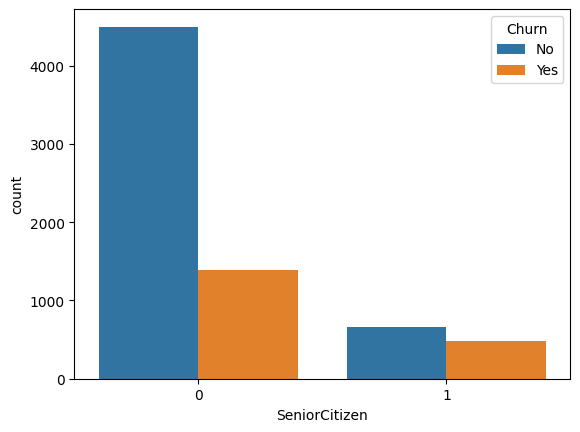

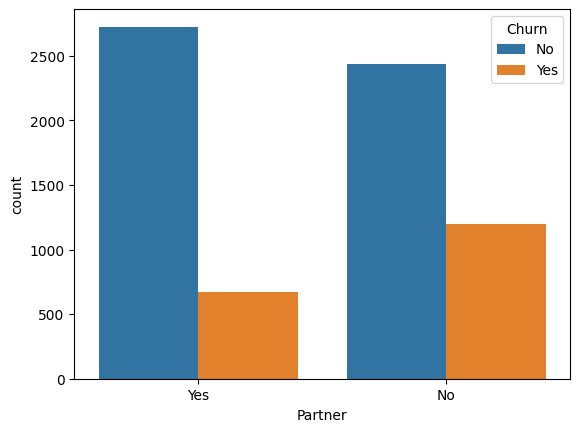

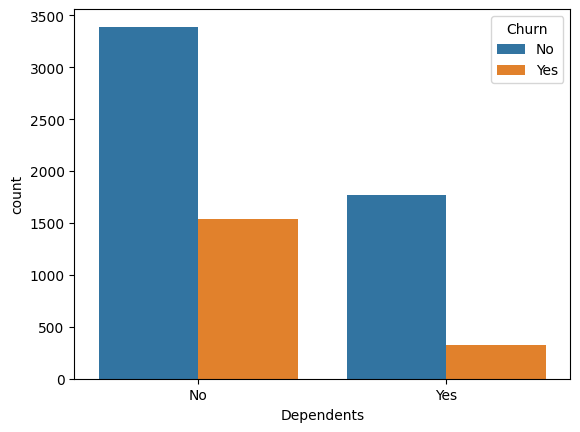

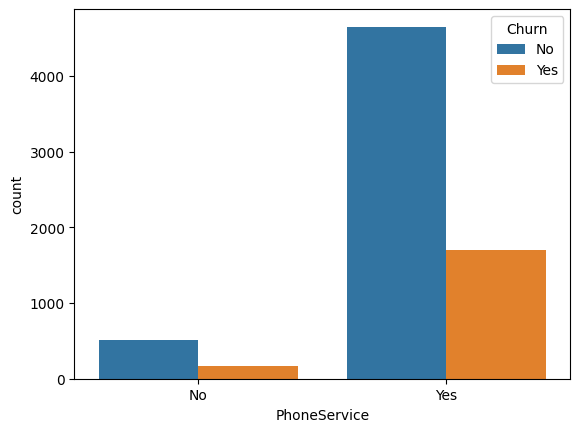

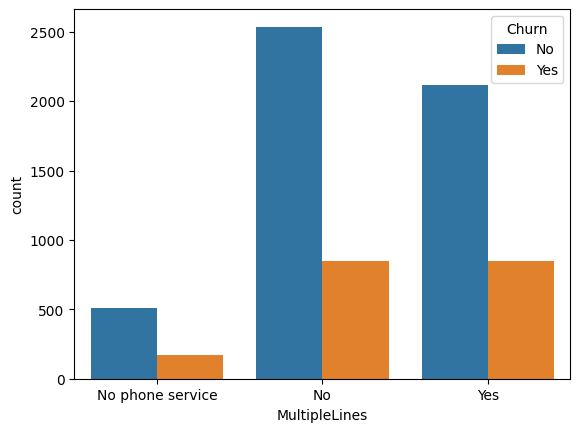

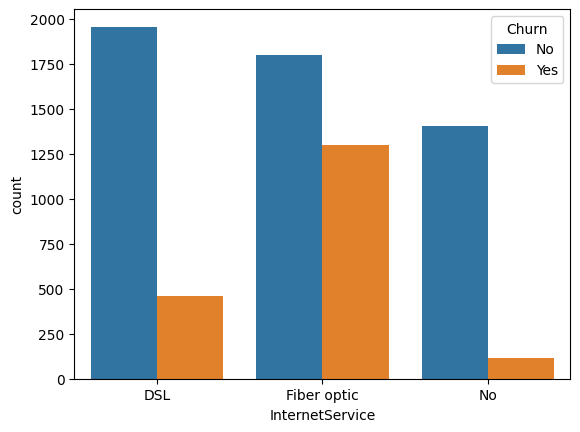

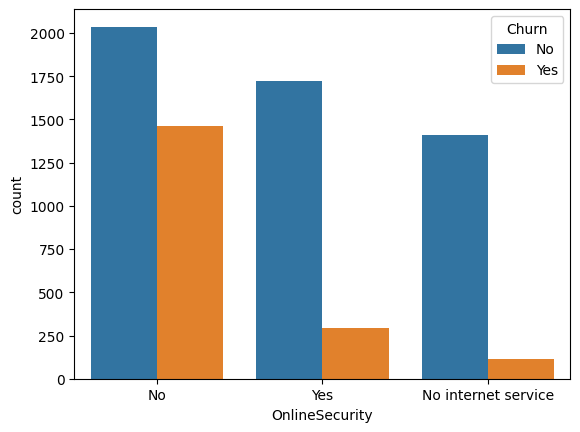

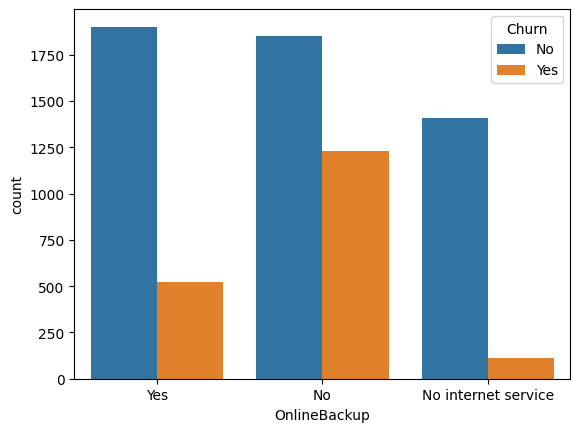

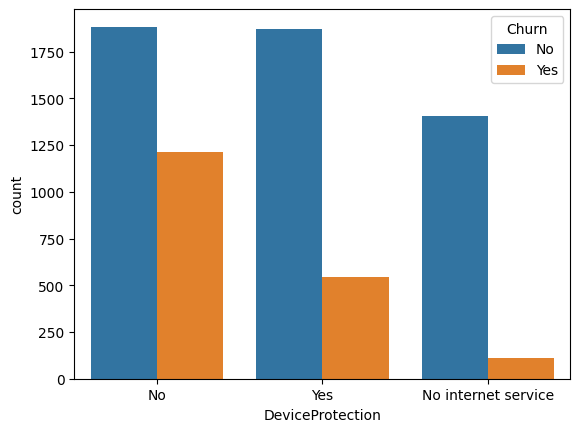

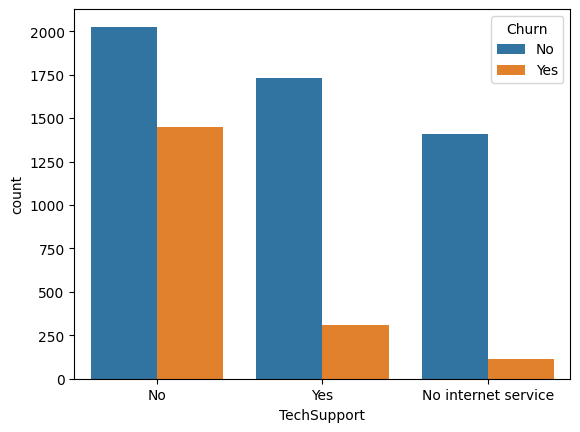

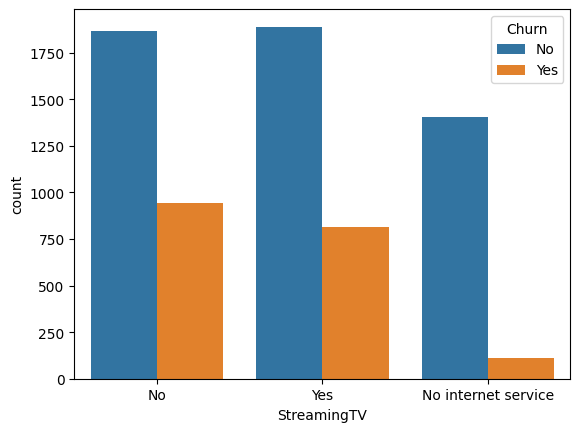

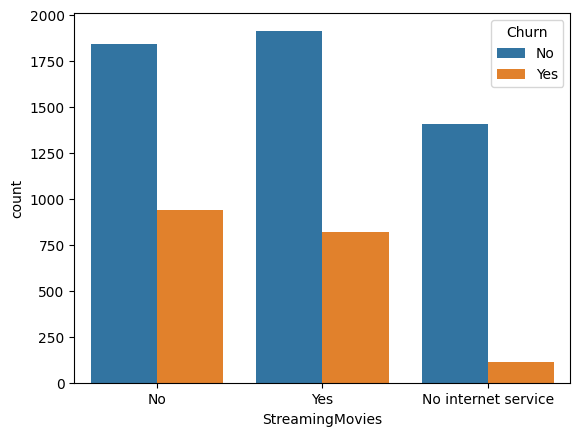

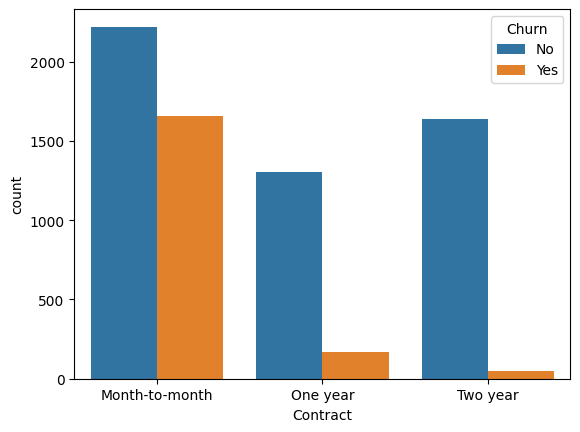

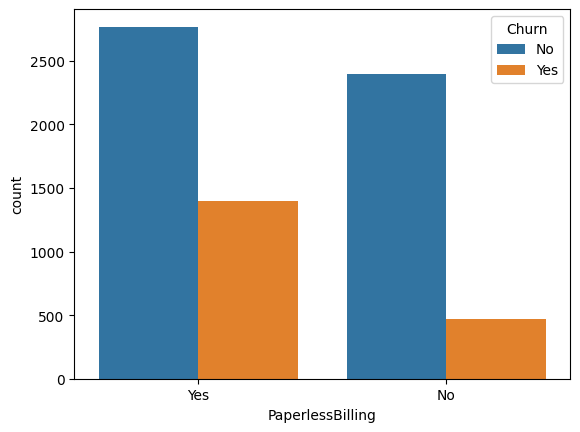

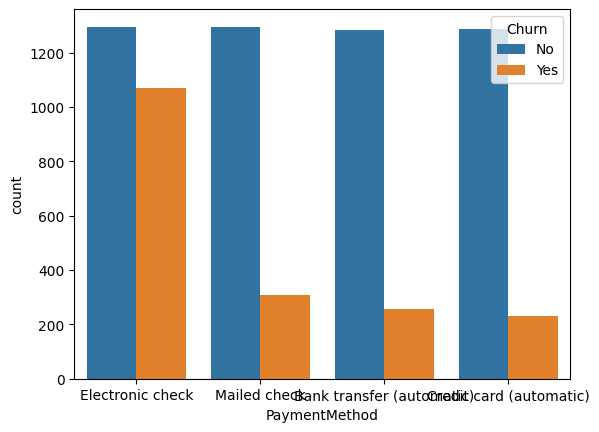

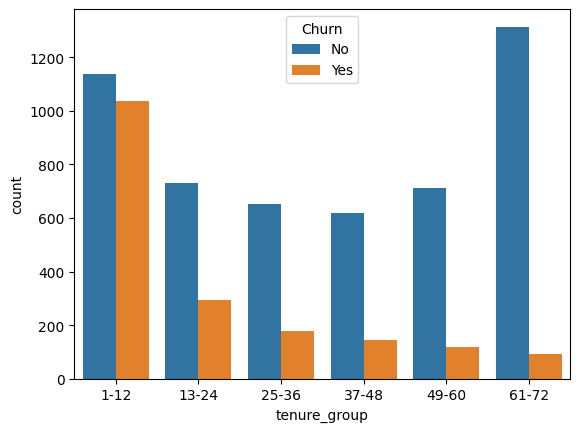

In [28]:
#Univariate ANalysis
for i, predictor in enumerate(telCom_base_Data.drop(columns=['Churn','TotalCharges','MonthlyCharges'])):
  plt.figure(i)
  sns.countplot(data=telCom_base_Data, x=predictor, hue='Churn')

In [29]:
import numpy as np

#Convert the Target variable 'Churn' in a binary numeric Variable i.e Yes=1, No = 0

telCom_base_Data['Churn'] = np.where(telCom_base_Data.Churn == 'Yes', 1,0)

In [30]:
telCom_base_Data.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1-12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,25-36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,1-12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,37-48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1-12


In [31]:
#Covert all the Categorical variables into dummy variable

telCom_base_Data_dummies = pd.get_dummies(telCom_base_Data)
telCom_base_Data_dummies.head()

,SeniorCitizen,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1-12,tenure_group_13-24,tenure_group_25-36,tenure_group_37-48,tenure_group_49-60,tenure_group_61-72
0,0,29.85,29.85,0,True,False,False,True,True,False,...,False,False,True,False,True,False,False,False,False,False
1,0,56.95,1889.50,0,False,True,True,False,True,False,...,False,False,False,True,False,False,True,False,False,False
2,0,53.85,108.15,1,False,True,True,False,True,False,...,False,False,False,True,True,False,False,False,False,False
3,0,42.30,1840.75,0,False,True,True,False,True,False,...,True,False,False,False,False,False,False,True,False,False
4,0,70.70,151.65,1,True,False,True,False,True,False,...,False,False,True,False,True,False,False,False,False,False


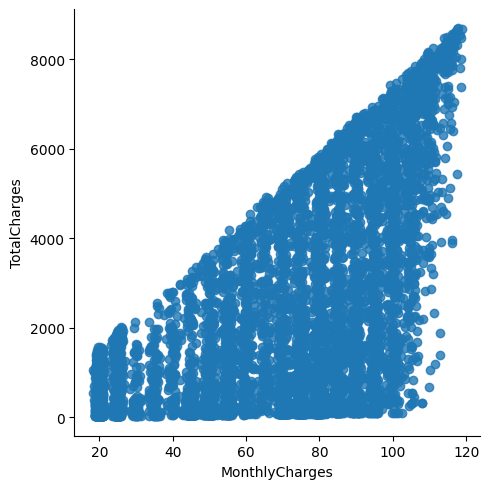

In [32]:
#Relationship between MOnthly Charges and totalCharges
sns.lmplot(data=telCom_base_Data_dummies, x = 'MonthlyCharges', y='TotalCharges', fit_reg=False)

#Linear Model Plot
#Ye scatter plot + regression line show karta hai.

/tmp/ipython-input-423/2546694254.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Monthly = sns.kdeplot(telCom_base_Data_dummies.MonthlyCharges[(telCom_base_Data_dummies['Churn'] == 0)],
/tmp/ipython-input-423/2546694254.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Monthly = sns.kdeplot(telCom_base_Data_dummies.MonthlyCharges[(telCom_base_Data_dummies['Churn'] == 1)],


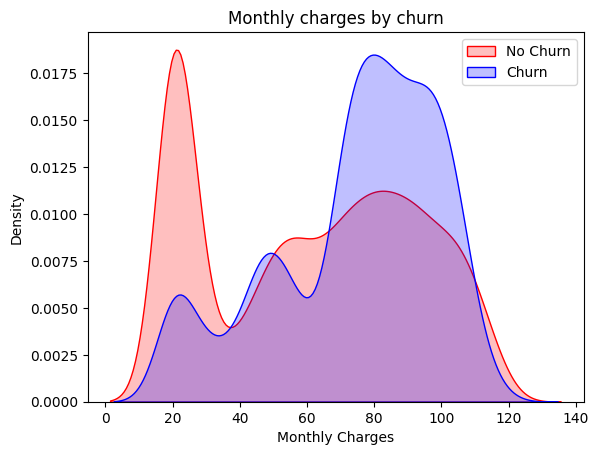

In [33]:
Monthly = sns.kdeplot(telCom_base_Data_dummies.MonthlyCharges[(telCom_base_Data_dummies['Churn'] == 0)],
                      color='Red', shade=True)
Monthly = sns.kdeplot(telCom_base_Data_dummies.MonthlyCharges[(telCom_base_Data_dummies['Churn'] == 1)],
                      ax = Monthly, color='Blue', shade=True)
Monthly.legend(["No Churn","Churn"],loc='upper right')
Monthly.set_ylabel("Density")
Monthly.set_xlabel("Monthly Charges")
Monthly.set_title("Monthly charges by churn")
plt.show()

This code plots the density distribution of MonthlyCharges for churned and non-churned customers using seaborn KDE plots. It helps compare how monthly charges differ between customers who left and those who stayed.

/tmp/ipython-input-423/1671069744.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Total = sns.kdeplot(telCom_base_Data_dummies.TotalCharges[(telCom_base_Data_dummies['Churn'] == 0)],
/tmp/ipython-input-423/1671069744.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Total = sns.kdeplot(telCom_base_Data_dummies.TotalCharges[(telCom_base_Data_dummies['Churn'] == 1)],


Text(0.5, 1.0, 'Total charges by Churn')

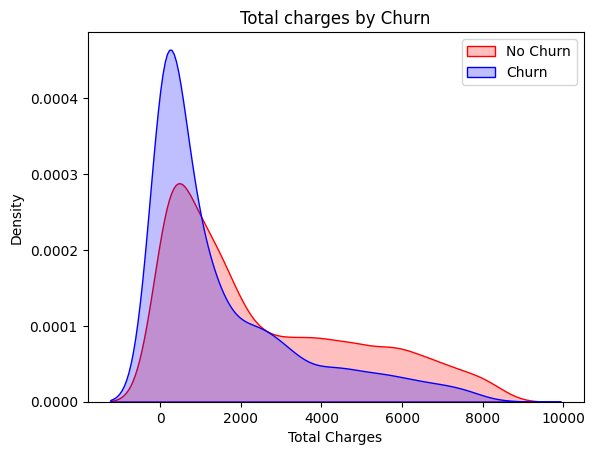

In [34]:
Total = sns.kdeplot(telCom_base_Data_dummies.TotalCharges[(telCom_base_Data_dummies['Churn'] == 0)],
                    color='Red', shade=True)
Total = sns.kdeplot(telCom_base_Data_dummies.TotalCharges[(telCom_base_Data_dummies['Churn'] == 1)],
                    ax = Total, color='Blue', shade=True)
Total.legend(["No Churn", "Churn"],loc='upper right')
Total.set_ylabel("Density")
Total.set_xlabel("Total Charges")
Total.set_title("Total charges by Churn")

<Axes: >

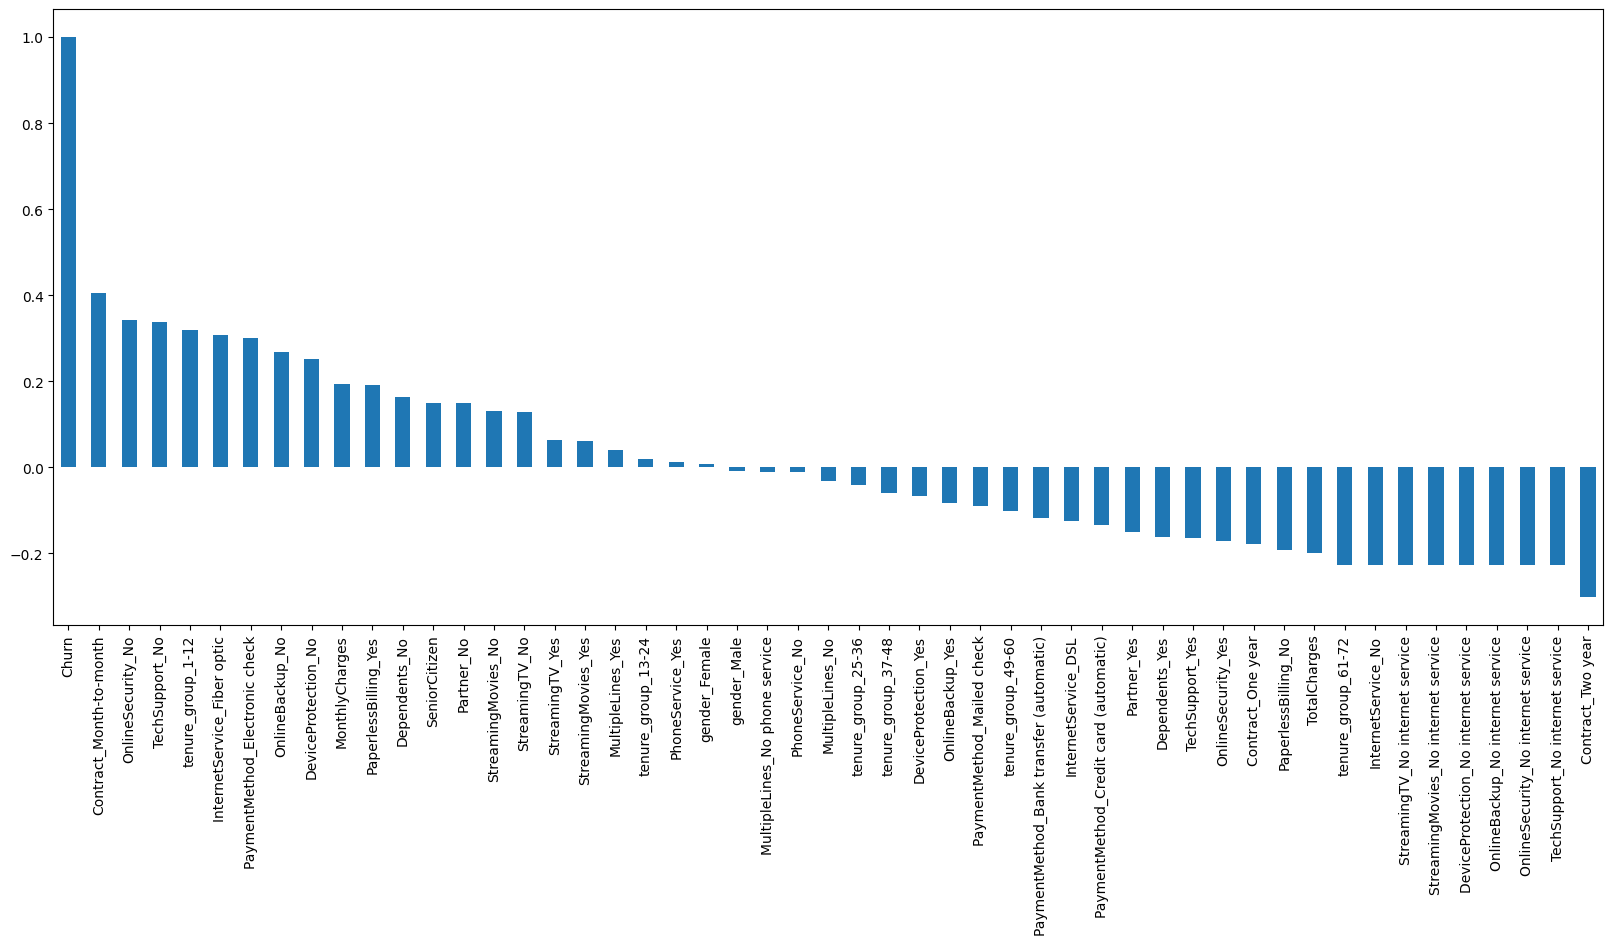

In [35]:
#Build a Correlation of all predictors with churn
plt.figure(figsize=(20,8))
telCom_base_Data_dummies.corr()['Churn'].sort_values(ascending = False).plot(kind = 'bar')

Low churn is seens in case of long term contracts, subscriptiona without internet service and customer engaged 5+more year
Factors like Gender, Availability of phone Service and many more have almost NOimpact on churn

<Axes: >

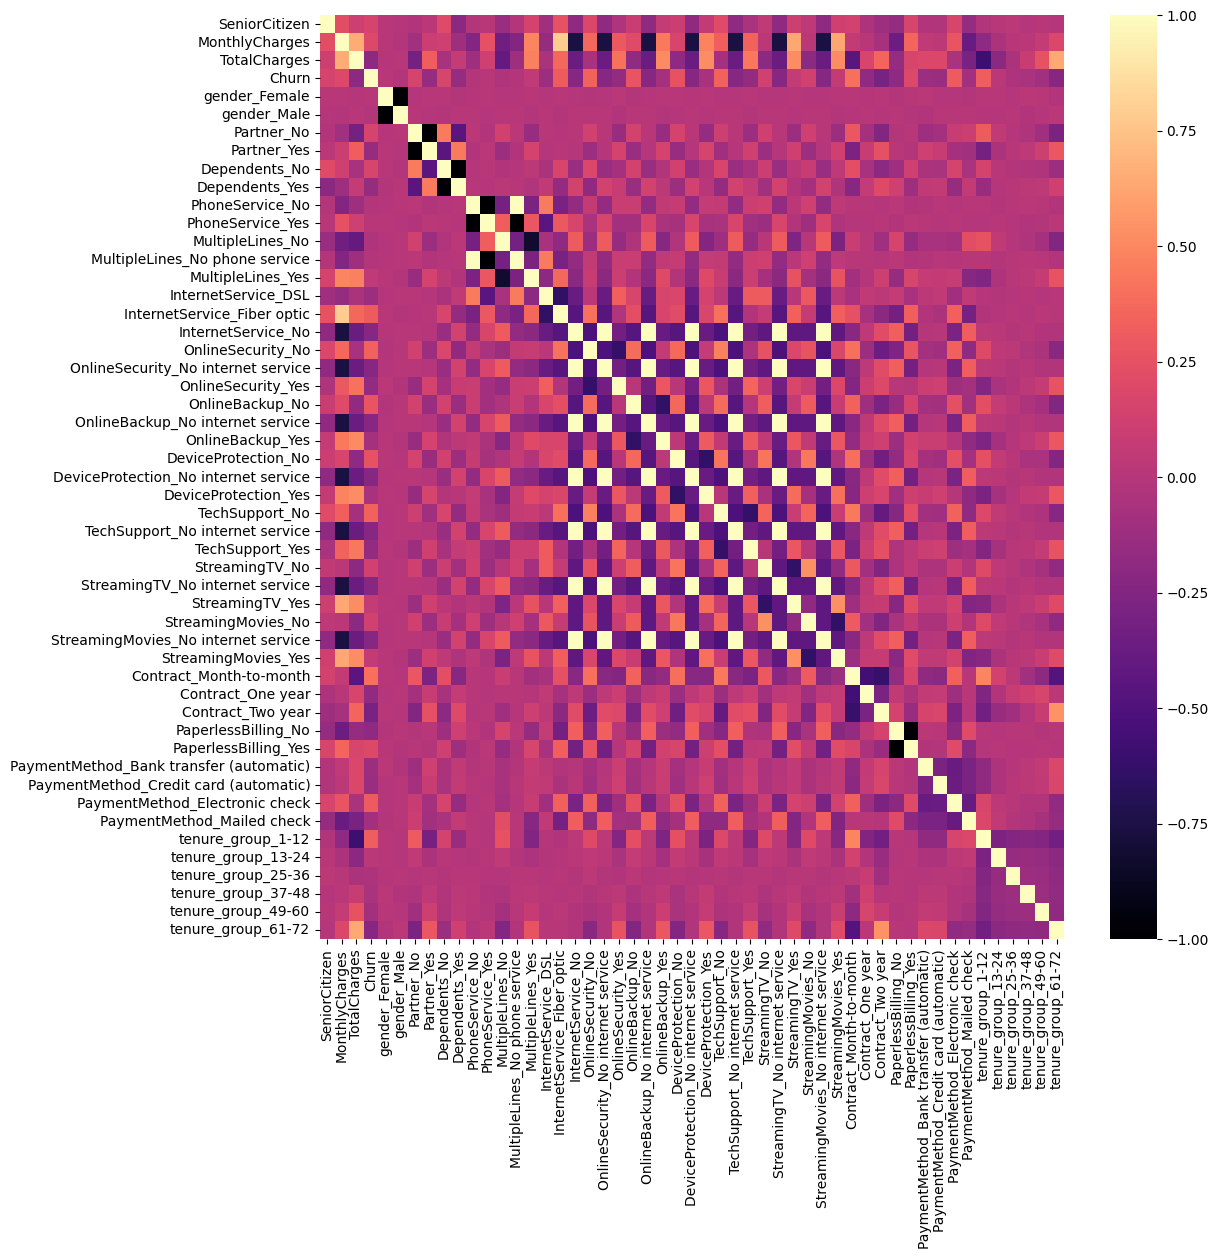

In [36]:
plt.figure(figsize=(12,12))
sns.heatmap(telCom_base_Data_dummies.corr(), cmap = "magma")

# **BIVARIATE ANALYSIS**

In [39]:
new_df1_target0=telCom_base_Data.loc[telCom_base_Data["Churn"]==0]
new_df1_target1=telCom_base_Data.loc[telCom_base_Data["Churn"]==1]

In [40]:
def uniplot(df,col,title,hue =None):

    sns.set_style('whitegrid')
    sns.set_context('talk')
    plt.rcParams["axes.labelsize"] = 20
    plt.rcParams['axes.titlesize'] = 22
    plt.rcParams['axes.titlepad'] = 30


    temp = pd.Series(data = hue)
    fig, ax = plt.subplots()
    width = len(df[col].unique()) + 7 + 4*len(temp.unique())
    fig.set_size_inches(width , 8)
    plt.xticks(rotation=45)
    #plt.yscale('log')
    plt.title(title)
    ax = sns.countplot(data = df, x= col, order=df[col].value_counts().index,hue = hue,palette='bright')


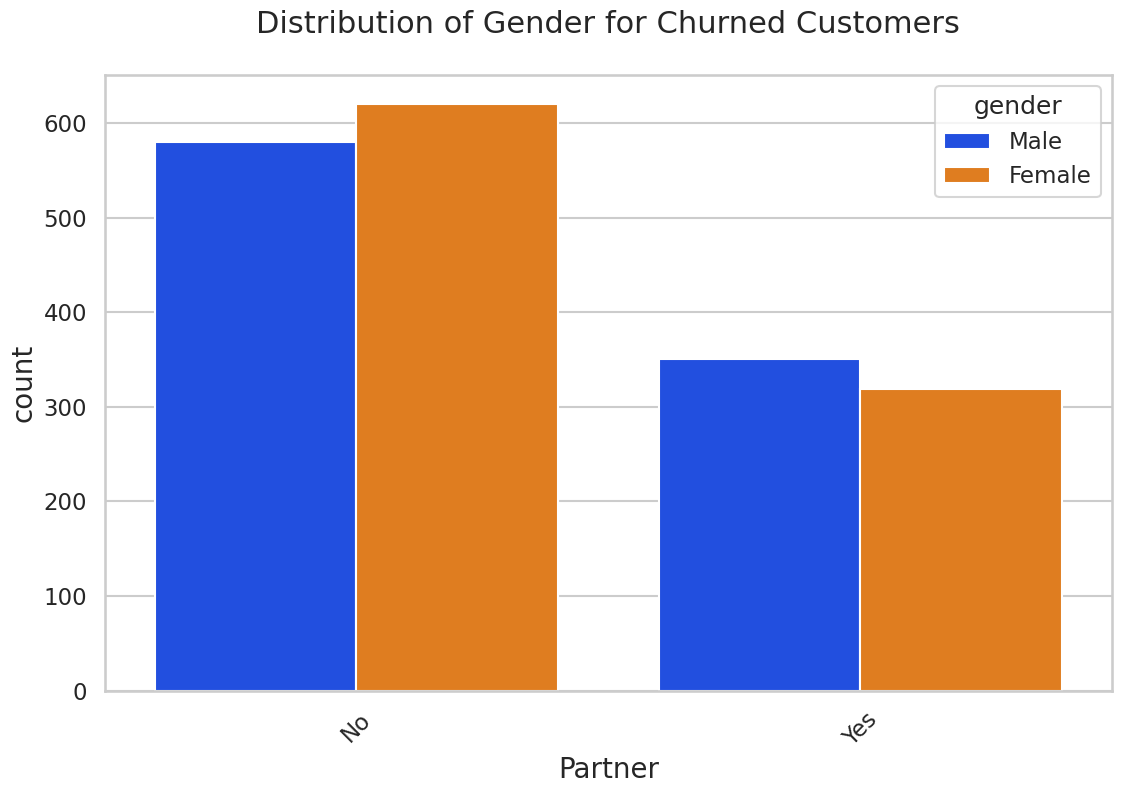

In [41]:
uniplot(new_df1_target1,col='Partner',title='Distribution of Gender for Churned Customers',hue='gender')


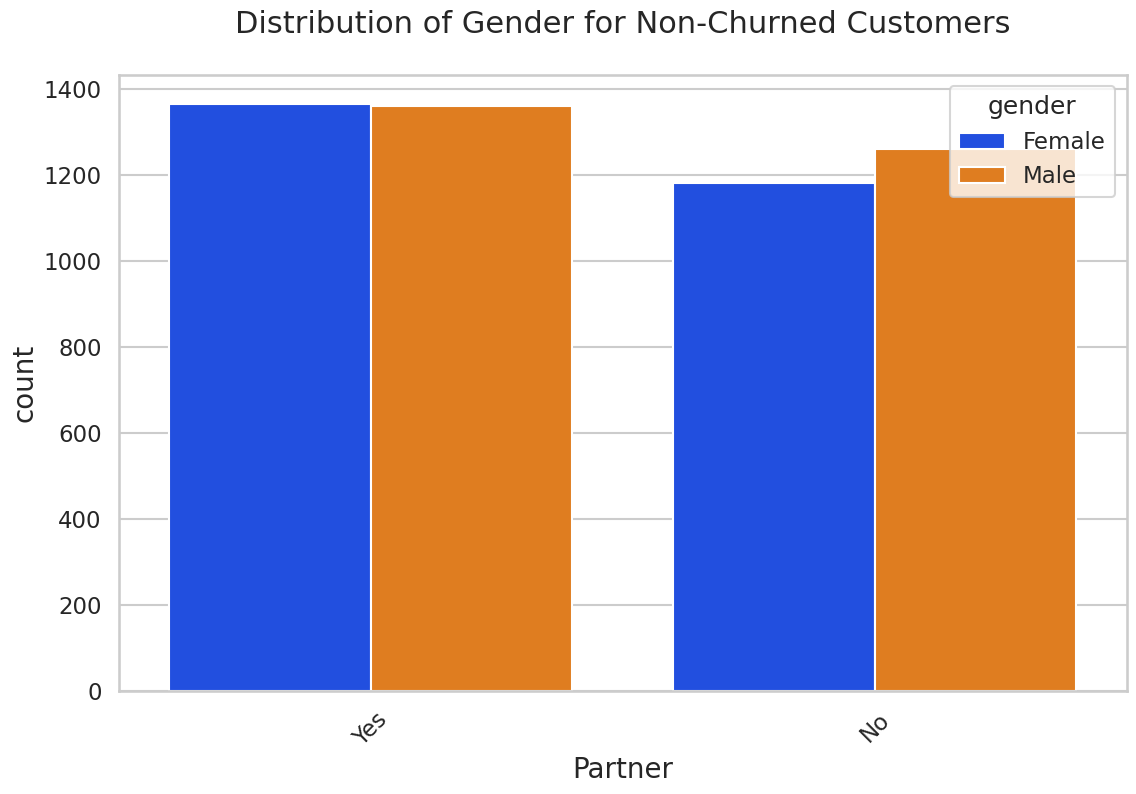

In [47]:
uniplot (new_df1_target0,col='Partner',title='Distribution of Gender for Non-Churned Customers', hue = 'gender')

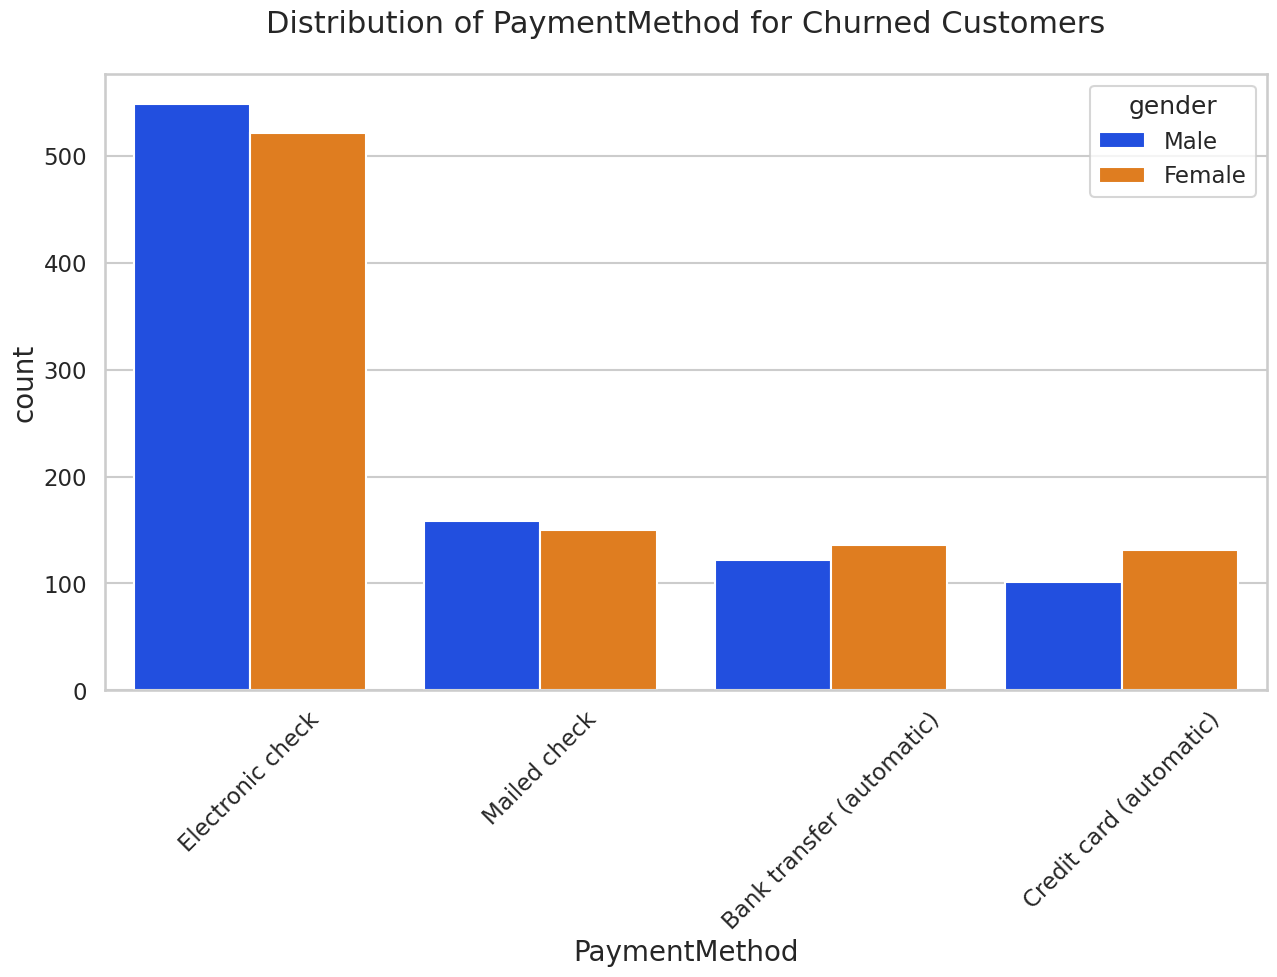

In [48]:
uniplot(new_df1_target1,col='PaymentMethod',title='Distribution of PaymentMethod for Churned Customers', hue='gender')

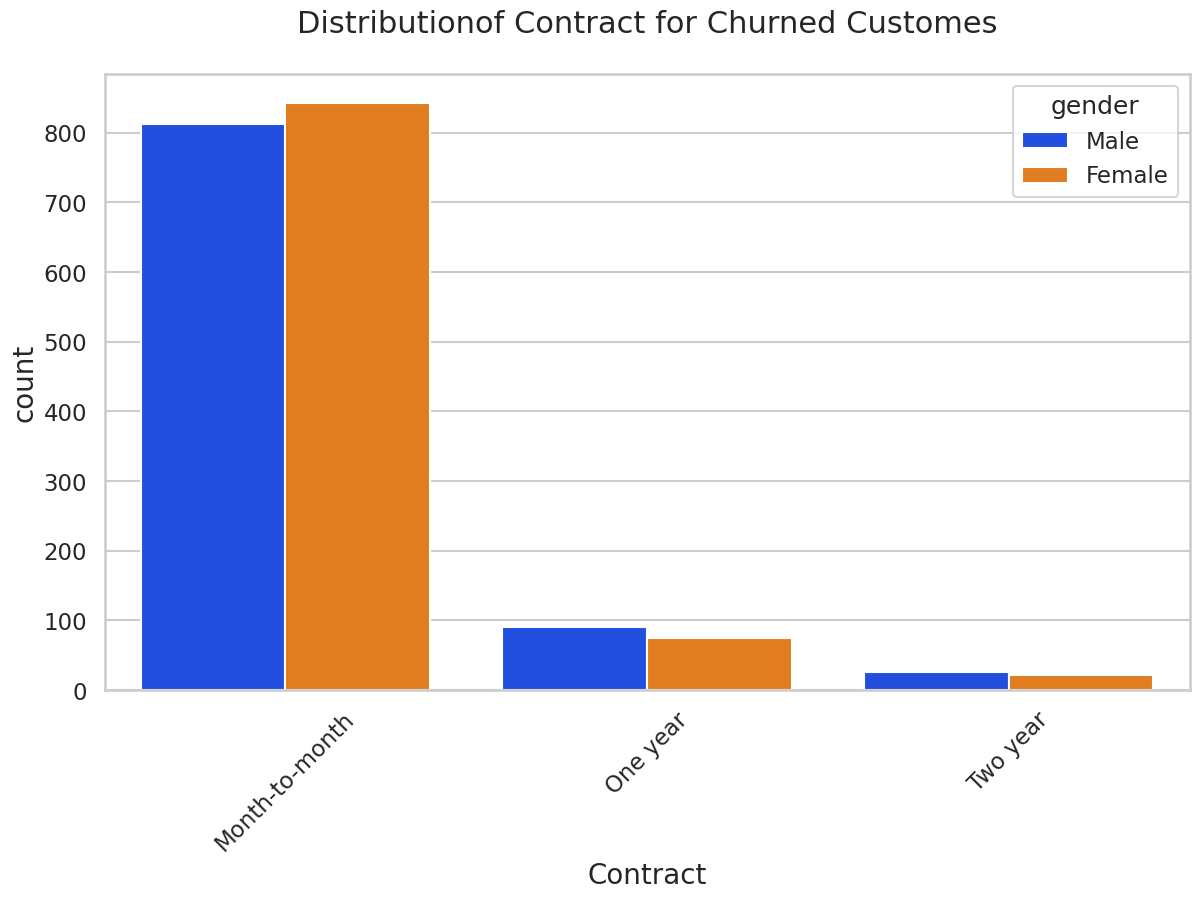

In [50]:
uniplot(new_df1_target1, col = 'Contract', title='Distributionof Contract for Churned Customes', hue='gender')

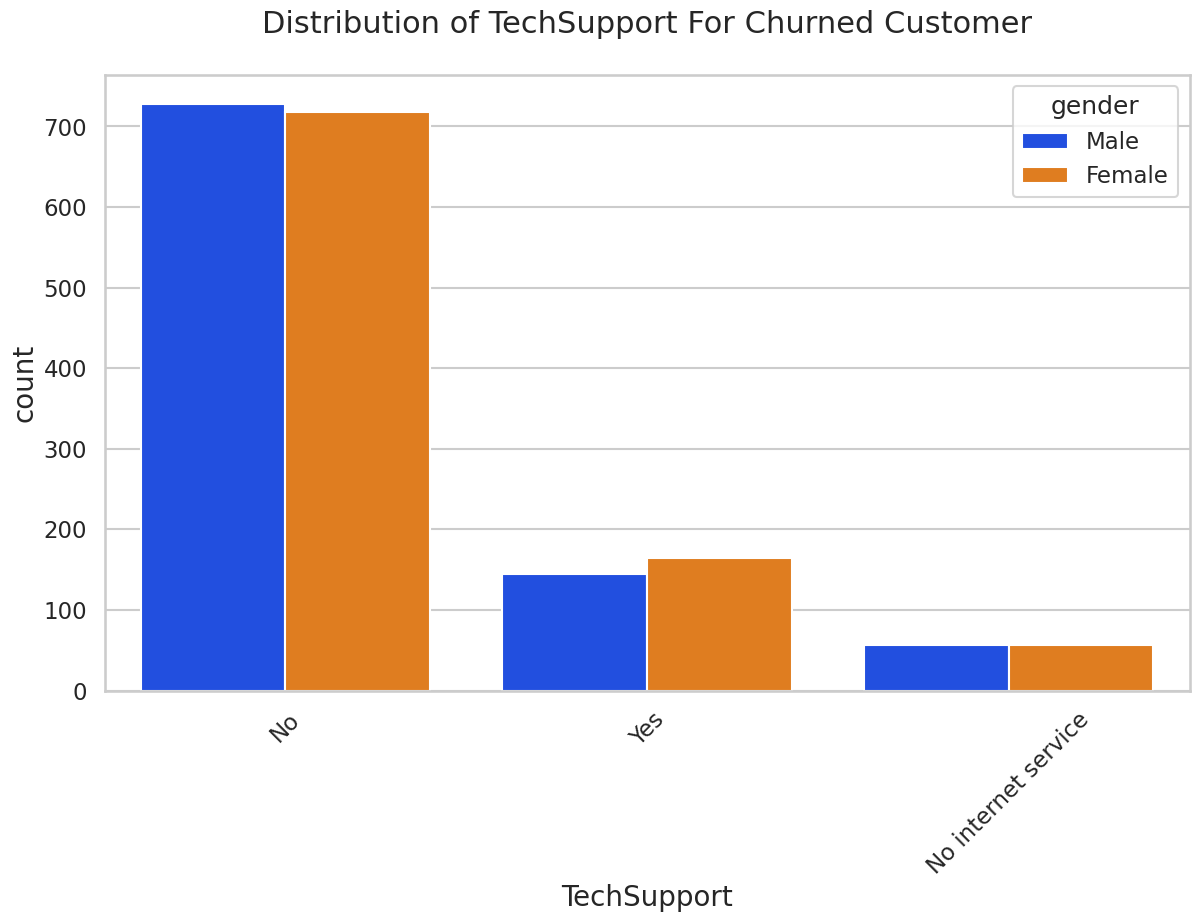

In [51]:
uniplot(new_df1_target1 ,col='TechSupport', title='Distribution of TechSupport For Churned Customer',hue='gender')

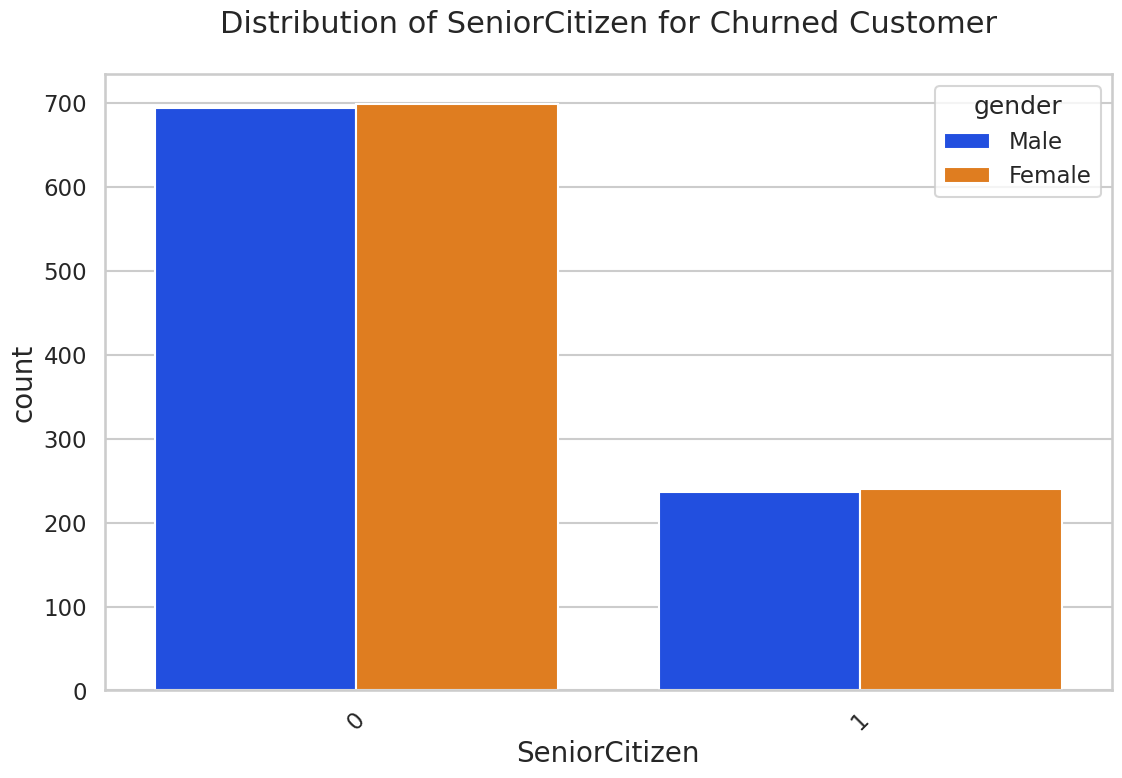

In [53]:
uniplot(new_df1_target1,col='SeniorCitizen', title='Distribution of SeniorCitizen for Churned Customer', hue ='gender')

# **CONCLUSION**

These are some of the quick insights from this exercise:

Electronic check medium are the highest churners
Contract Type - Monthly customers are more likely to churn because of no contract terms, as they are free to go customers.
No Online security, No Tech Support category are high churners
Non senior Citizens are high churners
Note: There could be many more such insights, so take this as an assignment and try to get more insights :)

In [54]:
telCom_base_Data_dummies.to_csv("Tel_Churn.csv")